## 서포터벡터머신(SVM)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv("../data/전처리완료.csv")

In [3]:
# 필요한 라이브러리 불러오기
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# 특징 변수(X)와 목표 변수(y) 분리
X = df.drop('고객이탈여부', axis=1)
y = df['고객이탈여부']

In [4]:
# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SVM 분류기 모델 생성 및 학습
svm_model = SVC(kernel='linear')  # 선형 커널을 사용한 SVM
svm_model.fit(X_train, y_train)

# 테스트 데이터에 대한 예측
y_pred = svm_model.predict(X_test)

In [5]:
# 성과평가 라이브러리 불러오기
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import roc_curve, roc_auc_score

# 평가
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall", recall_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7925
Precision: 0.3225806451612903
Recall 0.05089058524173028
f1_score 0.0879120879120879
Confusion Matrix:
 [[1565   42]
 [ 373   20]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.97      0.88      1607
           1       0.32      0.05      0.09       393

    accuracy                           0.79      2000
   macro avg       0.57      0.51      0.49      2000
weighted avg       0.71      0.79      0.73      2000



In [6]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[1565   42]
 [ 373   20]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.97      0.88      1607
           1       0.32      0.05      0.09       393

    accuracy                           0.79      2000
   macro avg       0.57      0.51      0.49      2000
weighted avg       0.71      0.79      0.73      2000



Feature importance: [2.13549417e+01 7.49634402e+01 1.71654172e+02 7.84132680e+02
 2.77501069e+01 6.47475868e-02 2.64527908e+01 1.73949924e+01
 3.13452791e+02 1.49247017e-01]
피처 중요도 (가중치): [-2.13549417e+01  7.49634402e+01 -1.71654172e+02  7.84132680e+02
 -2.77501069e+01 -6.47475868e-02 -2.64527908e+01  1.73949924e+01
 -3.13452791e+02 -1.49247017e-01]


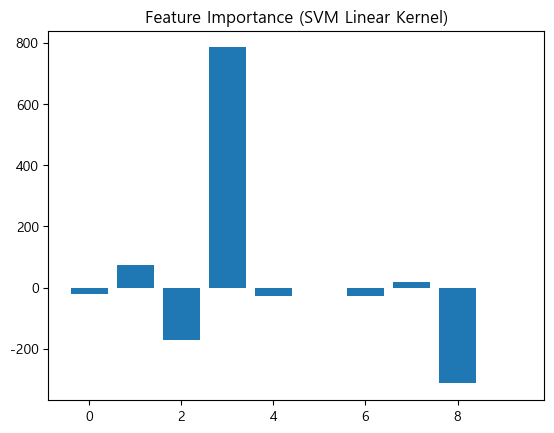

In [7]:
# coef_ 확인
importance = svm_model.coef_[0]
feature_importance = np.abs(svm_model.coef_[0])
print("Feature coef_:", feature_importance)

### 2) 비선형 모델 BEF 진행

In [8]:
# SVM 모델 생성 및 학습 (RBF 커널 사용)
svm_model_rbf = SVC(kernel='rbf', gamma='scale', C=1.0)
svm_model_rbf.fit(X_train, y_train)

# 테스트 데이터에 대한 예측
y_pred_rbf = svm_model_rbf.predict(X_test)

In [9]:
# 성과평가 라이브러리 불러오기
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import roc_curve, roc_auc_score

# 평가
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("Precision:", precision_score(y_test, y_pred_rbf))
print("Recall", recall_score(y_test, y_pred_rbf))
print("f1_score", f1_score(y_test, y_pred_rbf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))
print("Classification Report:\n", classification_report(y_test, y_pred_rbf))

Accuracy: 0.8035
Precision: 0.0
Recall 0.0
f1_score 0.0
Confusion Matrix:
 [[1607    0]
 [ 393    0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89      1607
           1       0.00      0.00      0.00       393

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.65      0.80      0.72      2000



c:\Users\OPERATOR-70\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\OPERATOR-70\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\OPERATOR-70\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [10]:
from sklearn.model_selection import GridSearchCV

# 하이퍼파라미터 그리드 정의
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

# GridSearchCV를 사용한 모델 최적화
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2)
grid.fit(X_train, y_train)

# 최적 하이퍼파라미터 출력
print("최적 하이퍼파라미터: ", grid.best_params_)

# 최적화된 모델을 사용하여 테스트 데이터에 대한 예측 및 평가
grid_predictions = grid.predict(X_test)
accuracy_optimized = accuracy_score(y_test, grid_predictions)
print(f"SVM 분류기 정확도 (최적화된 RBF 커널): {accuracy_optimized * 100:.2f}%")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   2.1s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   1.9s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   1.9s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   2.1s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   2.1s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   1.9s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   1.9s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   1.9s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   2.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   2.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   2.2s
[CV] END ......................C=0.1, gamma=0.01

In [11]:
from sklearn.inspection import permutation_importance

# Permutation Importance 계산
perm_importance = permutation_importance(svm_model_rbf, X_test, y_test)

# 중요도 출력
print("Feature importances:", perm_importance.importances_mean)

Feature importances: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### 3) Polynomial

In [12]:
# SVM 모델 생성 및 학습 (Polynomial 커널 사용)
svm_model_poly = SVC(kernel='poly', degree=3, C=1.0, gamma='scale')
svm_model_poly.fit(X_train, y_train)

# 테스트 데이터에 대한 예측
y_pred_poly = svm_model_poly.predict(X_test)

# 정확도 평가
accuracy_poly = accuracy_score(y_test, y_pred_poly)
print(f"SVM 분류기 정확도 (Polynomial 커널): {accuracy_poly * 100:.2f}%")

SVM 분류기 정확도 (Polynomial 커널): 80.35%


In [13]:
# 성과평가 라이브러리 불러오기
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import roc_curve, roc_auc_score

# 평가
print("Accuracy:", accuracy_score(y_test, y_pred_poly))
print("Precision:", precision_score(y_test, y_pred_poly))
print("Recall", recall_score(y_test, y_pred_poly))
print("f1_score", f1_score(y_test, y_pred_poly))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_poly))
print("Classification Report:\n", classification_report(y_test, y_pred_poly))

Accuracy: 0.8035
Precision: 0.0
Recall 0.0
f1_score 0.0
Confusion Matrix:
 [[1607    0]
 [ 393    0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89      1607
           1       0.00      0.00      0.00       393

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.65      0.80      0.72      2000



c:\Users\OPERATOR-70\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\OPERATOR-70\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\OPERATOR-70\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

### 4) sigmoid

In [14]:
# SVM 모델 생성 및 학습 (Sigmoid 커널 사용)
svm_model_sigmoid = SVC(kernel='sigmoid', C=1.0, gamma='scale')
svm_model_sigmoid.fit(X_train, y_train)

# 테스트 데이터에 대한 예측
y_pred_sigmoid = svm_model_sigmoid.predict(X_test)

# 정확도 평가
accuracy_sigmoid = accuracy_score(y_test, y_pred_sigmoid)
print(f"SVM 분류기 정확도 (Sigmoid 커널): {accuracy_sigmoid * 100:.2f}%")

SVM 분류기 정확도 (Sigmoid 커널): 68.30%


In [15]:
# 성과평가 라이브러리 불러오기
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import roc_curve, roc_auc_score

# 평가
print("Accuracy:", accuracy_score(y_test, y_pred_sigmoid))
print("Precision:", precision_score(y_test, y_pred_sigmoid))
print("Recall", recall_score(y_test, y_pred_sigmoid))
print("f1_score", f1_score(y_test, y_pred_sigmoid))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_sigmoid))
print("Classification Report:\n", classification_report(y_test, y_pred_sigmoid))

Accuracy: 0.683
Precision: 0.21377672209026127
Recall 0.22900763358778625
f1_score 0.22113022113022113
Confusion Matrix:
 [[1276  331]
 [ 303   90]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.79      0.80      1607
           1       0.21      0.23      0.22       393

    accuracy                           0.68      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.69      0.68      0.69      2000



### 5) 그리드 서치(시간 오래걸림)


In [ ]:
# SVM에 사용할 하이퍼파라미터 그리드 정의
param_grid = {
    'C': [0.1, 1, 10, 100],      # Regularization parameter
    'gamma': ['scale', 'auto', 0.01, 0.001],  # Kernel coefficient
    'kernel': ['rbf', 'poly', 'sigmoid']     # Kernel types
}

# GridSearchCV 설정 (교차 검증 포함)
grid_search = GridSearchCV(SVC(), param_grid, cv=5, verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 최적의 하이퍼파라미터와 성능 출력
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.2f}")

# 최적 하이퍼파라미터로 테스트 데이터 예측
best_svm_model = grid_search.best_estimator_
y_pred = best_svm_model.predict(X_test)

# 테스트 데이터에 대한 성능 평가
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
